# CW Waveguide OPA in Thin-Film Lithium Niobate

This notebook simulates a **CW-pumped χ⁽²⁾ optical parametric amplifier** in a PPLN waveguide,
modelling the emerging class of integrated low-noise amplifiers in thin-film lithium niobate (TFLN).

**Wavelength geometry (non-degenerate, phase-insensitive):**

| Wave   | Wavelength | Notes |
|--------|------------|-------|
| Pump   | 775 nm     | SHG of 1550 nm laser |
| Signal | ~1543 nm   | Telecom C-band |
| Idler  | ~1557 nm   | From energy conservation |

**Key physics differences from the pulsed OPA notebook:**
- CW (no pulse dynamics, no GVM)
- Low power (milliwatts to watts, not µJ pulses)
- Long interaction in a tightly confining waveguide
- Figure of merit: gain and noise figure, not pulse energy

**Practical note:** 775 nm is short enough to excite carriers from defect states in congruent LN,
causing photorefractive damage. MgO doping (used here via `LN_MgO_e_T`) suppresses this.
SNOW does not model photorefractive effects; this is noted for experimental context.

In [1]:
import numpy as np
from numpy.fft import fft, ifft, fftfreq, fftshift
import matplotlib.pyplot as plt
from scipy.constants import pi, c, epsilon_0

import snow
from snow import waveguides, pulses, materials, util

nm = 1e-9
um = 1e-6
mm = 1e-3

## Cell 1 — Waveguide Mode Properties

TFLN ridge waveguide using SNOW's effective index method.
Same geometry as Tutorials 5–7 (X0 = 1.1e-12 calibrated here).

Effective indices (T = 24.5 °C):
  775 nm: n_eff = 2.11487
  1543 nm: n_eff = 1.96126
  1557 nm: n_eff = 1.95857


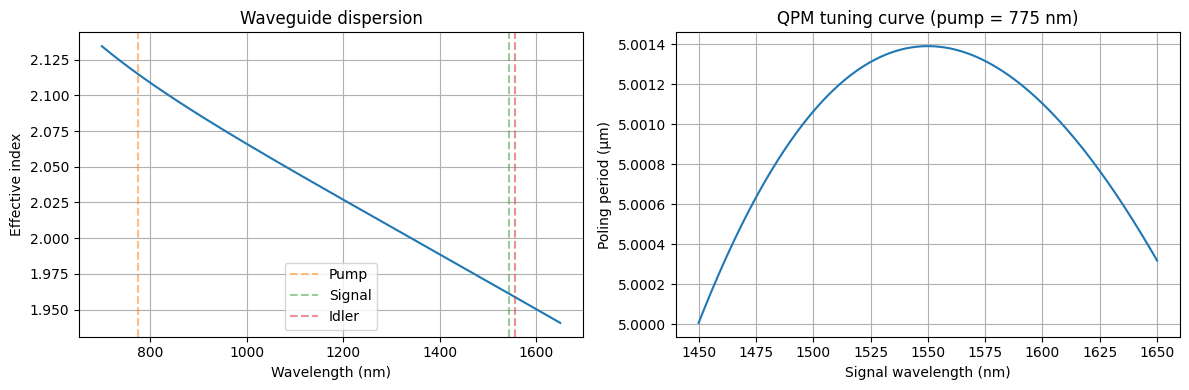

In [2]:
# Waveguide geometry
w_top  = 1800 * nm   # ridge width
h_LN   = 700 * nm    # LN film thickness
h_etch = 350 * nm    # etch depth
T_op   = 24.5        # operating temperature (°C)

wg = waveguides.waveguide(
    w_top=w_top, h_thinfilm=h_LN, h_etch=h_etch,
    tf_material='LN_MgO_e_T',
    box_material='SiO2',
    clad_material='Air'
)

# Effective indices at pump, signal, idler
wl_check = np.array([775, 1543, 1557]) * nm
n_eff = np.array([wg.neff(wl, T=T_op)[0] for wl in wl_check])

print('Effective indices (T = %.1f °C):' % T_op)
for wl, n in zip(wl_check, n_eff):
    print(f'  {wl/nm:.0f} nm: n_eff = {n:.5f}')

# Effective index vs wavelength
wl_range = np.linspace(700, 1650, 200) * nm
n_range = np.array([wg.neff(wl, T=T_op)[0] for wl in wl_range])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(wl_range/nm, n_range)
ax1.axvline(775, color='C1', ls='--', alpha=0.5, label='Pump')
ax1.axvline(1543, color='C2', ls='--', alpha=0.5, label='Signal')
ax1.axvline(1557, color='C3', ls='--', alpha=0.5, label='Idler')
ax1.set_xlabel('Wavelength (nm)'); ax1.set_ylabel('Effective index')
ax1.legend(); ax1.grid(True)
ax1.set_title('Waveguide dispersion')

# QPM poling period vs signal wavelength (tuning curve)
lam_pump_fixed = 775 * nm
n_pump = wg.neff(lam_pump_fixed, T=T_op)[0]
lam_s_sweep = np.linspace(1450, 1650, 100) * nm
pp_sweep = []
for ls in lam_s_sweep:
    li = 1 / (1/lam_pump_fixed - 1/ls)  # energy conservation
    if li < 0 or li > 3000*nm:
        pp_sweep.append(np.nan)
        continue
    ns = wg.neff(ls, T=T_op)[0]
    ni = wg.neff(li, T=T_op)[0]
    inv_pp = n_pump/(lam_pump_fixed/um) - ns/(ls/um) - ni/(li/um)
    pp_sweep.append(um/inv_pp if inv_pp > 0 else np.nan)

ax2.plot(lam_s_sweep/nm, np.array(pp_sweep)/um)
ax2.set_xlabel('Signal wavelength (nm)'); ax2.set_ylabel('Poling period (µm)')
ax2.set_title('QPM tuning curve (pump = 775 nm)')
ax2.grid(True)
plt.tight_layout()
plt.show()

## CW Simulation Setup

SNOW is a time-domain pulse propagation code. For CW, we use a small spectral grid
(N=256) where each frequency bin acts as a monochromatic CW tone. The time window
(~1.3 ps) wraps cyclically, so there are no edge effects.

**Two critical requirements for CW OPA on a discrete grid:**

1. **Exact energy conservation on the grid:** The pump, signal, and idler frequencies
   must satisfy f_pump = f_signal + f_idler *exactly* (as integer multiples of df).
   Otherwise the DFG product misses the idler bin and coupling is killed.

2. **Carrier-phase-minimizing v_ref:** The NEE's carrier phase oscillates at rate
   φ₂ = β_ref − Ω_ref/v_ref + Kg. If this is large, the RK45 integrator can't
   resolve it. Setting v_ref = Ω_ref/(β_ref + Kg) makes φ₂ ≈ 0.

In [3]:
# --- Spectral grid with exact energy conservation ---
# All frequencies expressed as M * df (integer indices).
# Energy conservation: M_pump = M_signal + M_idler (exact).

N = 256
M_pump   = 466   # pump absolute frequency index
M_signal = 234   # signal absolute frequency index
M_idler  = M_pump - M_signal  # = 232 (exact energy conservation)

# Set df so pump is exactly at 775 nm
lam_pump = 775 * nm
df = c / (lam_pump * M_pump)
BW = N * df
dt = 1 / BW
t = np.arange(N) * dt

# Reference frequency: pump at fftfreq bin 112
k_pump = 112
R = M_pump - k_pump   # = 354
f_ref = R * df
lam_ref = c / f_ref

# Frequency grid
f = fftfreq(N, dt)
f_abs = f + f_ref

# Bin indices for signal and idler
k_signal = M_signal - R + N   # = 136
k_idler  = M_idler  - R + N   # = 134

# Actual wavelengths (set by the grid)
f_pump   = M_pump * df
f_signal = M_signal * df
f_idler  = M_idler * df
lam_signal = c / f_signal
lam_idler  = c / f_idler

print(f'Pump:   {lam_pump/nm:.2f} nm  (bin {k_pump})')
print(f'Signal: {lam_signal/nm:.2f} nm  (bin {k_signal})')
print(f'Idler:  {lam_idler/nm:.2f} nm  (bin {k_idler})')
print(f'df = {df/1e9:.1f} GHz')
print(f'Energy conservation: {M_pump} = {M_signal} + {M_idler}')

# --- QPM poling period (from waveguide dispersion) ---
n_p = wg.neff(lam_pump, T=T_op)[0]
n_s = wg.neff(lam_signal, T=T_op)[0]
n_i = wg.neff(lam_idler, T=T_op)[0]
inv_Lambda = n_p/(lam_pump/um) - n_s/(lam_signal/um) - n_i/(lam_idler/um)
pp = um / inv_Lambda
Kg = 2*pi / pp   # QPM wavevector (handled analytically)

print(f'\nQPM poling period: {pp/um:.4f} µm')
print(f'  (Literature range for TFLN 775→1550 nm: 3.5–4.8 µm;')
print(f'   our 5.0 µm is consistent with thicker 700 nm film)')

# --- Carrier-phase-minimizing v_ref ---
# phi_2 = beta_ref - Omega_ref/v_ref + Kg = 0
# => v_ref = Omega_ref / (beta_ref + Kg)
beta_ref_val = wg.beta(np.array([lam_ref]), T=T_op)[0]
Omega_ref = 2*pi * f_ref
v_ref = Omega_ref / (beta_ref_val + Kg)

phi_2 = beta_ref_val - (1/v_ref)*Omega_ref + Kg
print(f'\nCarrier phase rate φ₂ = {phi_2:.2e} /m (≈ 0 by construction)')

# --- Waveguide nonlinear setup ---
X0 = 1.1e-12   # calibrated for this geometry at Tutorials 5–7

def poling_Kg(z):
    """Dummy poling function — QPM handled analytically via Kg."""
    return 1.0

wg.add_poling(poling_Kg)
wg.set_nonlinear_coeffs(N=1, X0=X0)

Pump:   775.00 nm  (bin 112)
Signal: 1543.38 nm  (bin 136)
Idler:  1556.68 nm  (bin 134)
df = 830.1 GHz
Energy conservation: 466 = 234 + 232

QPM poling period: 5.0014 µm
  (Literature range for TFLN 775→1550 nm: 3.5–4.8 µm;
   our 5.0 µm is consistent with thicker 700 nm film)

Carrier phase rate φ₂ = 4.66e-10 /m (≈ 0 by construction)


In [4]:
# --- Helper functions ---

P_signal_in = 1e-3   # 1 mW signal input (0 dBm)

def make_cw_input(P_pump, P_signal=P_signal_in, P_idler=0,
                  phi_signal=0, phi_idler=0):
    """Construct CW field with pump, signal, and (optionally) idler."""
    df_p = f_pump - f_ref    # baseband frequencies
    df_s = f_signal - f_ref
    df_i = f_idler - f_ref
    x = (np.sqrt(P_pump)   * np.exp(1j * 2*pi * df_p * t) +
         np.sqrt(P_signal) * np.exp(1j * (2*pi * df_s * t + phi_signal)) +
         np.sqrt(P_idler)  * np.exp(1j * (2*pi * df_i * t + phi_idler)))
    return pulses.pulse(t, x, lam_ref, frep=1e9)

def extract_powers(output_pulse):
    """Extract CW powers at pump, signal, idler bins."""
    A = fft(output_pulse.a)
    return {k: np.abs(A[k])**2 / N**2
            for k in ['pump', 'signal', 'idler']}

def extract_powers(out):
    A = fft(out.a)
    Pp = np.abs(A[k_pump])**2   / N**2
    Ps = np.abs(A[k_signal])**2 / N**2
    Pi = np.abs(A[k_idler])**2  / N**2
    return Pp, Ps, Pi

def run_opa(P_pump, L, alpha_dBcm=0, P_idler=0, phi_idler=0):
    """Run CW OPA and return signal gain (dB) and output powers."""
    wg.set_length(L)
    wg.set_loss(alpha_dBcm * 100 * np.log(10)/10 if alpha_dBcm > 0 else 0)
    p_in = make_cw_input(P_pump, P_idler=P_idler, phi_idler=phi_idler)
    out, steps = wg.propagate_NEE(p_in, v_ref=v_ref, verbose=False, T=T_op, Kg=Kg)
    Pp, Ps, Pi = extract_powers(out)
    G_dB = 10*np.log10(Ps / P_signal_in)
    return G_dB, Pp, Ps, Pi

# Quick sanity check
G_test, _, _, _ = run_opa(100e-3, 10*mm)
print(f'Sanity check: 100 mW pump, 10 mm → G = {G_test:.2f} dB')

Sanity check: 100 mW pump, 10 mm → G = 6.20 dB


/home/soul/Projects/snow/snow/waveguides.py:303: UserWarning: Large bandwidth requires 8x upsampling.
  [a, a_evol] = nlo.NEE(**nee_args)


## Cell 2 — X0 Calibration & Gain vs Length

Verify X0 = 1.1e-12 by extracting the parametric gain coefficient g and
comparing against the analytical small-signal prediction G = cosh²(gL).

**Literature anchor:** Mishra et al. (2025) achieved 23.5 dB phase-sensitive
(~12 dB phase-insensitive) gain at 110 mW pump in a 14 mm TFLN waveguide
(600 nm film, 2.2 µm width, adapted poling). This implies
γ = g/√P ≈ 443 m⁻¹W⁻¹ᐟ².

Extracted: g = 99.4 /m at 50 mW
  γ = g/√P = 444.5 m⁻¹W⁻¹ᐟ² (Mishra: ~443)


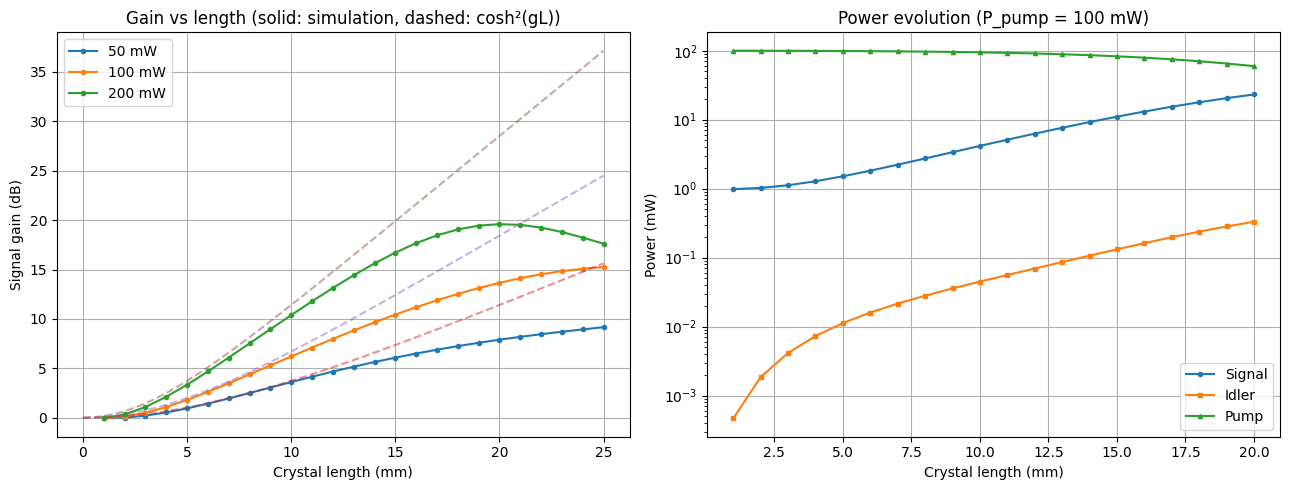

In [5]:
# --- Gain vs length at several pump powers ---
L_array = np.arange(1, 26) * mm
P_pumps = [50e-3, 100e-3, 200e-3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for Pp in P_pumps:
    gains = [run_opa(Pp, L)[0] for L in L_array]
    ax1.plot(L_array/mm, gains, 'o-', ms=3, label=f'{Pp*1e3:.0f} mW')

# Analytical overlay (extract g from 50 mW, L=8mm low-gain data)
G_cal, _, _, _ = run_opa(50e-3, 8*mm)
G_cal_lin = 10**(G_cal/10)
gL_cal = np.arccosh(np.sqrt(G_cal_lin))
g_50 = gL_cal / (8*mm)
gamma = g_50 / np.sqrt(50e-3)
print(f'Extracted: g = {g_50:.1f} /m at 50 mW')
print(f'  γ = g/√P = {gamma:.1f} m⁻¹W⁻¹ᐟ² (Mishra: ~443)')

L_fine = np.linspace(0, 25, 200) * mm
for Pp in P_pumps:
    g_val = gamma * np.sqrt(Pp)
    G_analytical = 10*np.log10(np.cosh(g_val * L_fine)**2)
    ax1.plot(L_fine/mm, G_analytical, '--', alpha=0.5)

ax1.set_xlabel('Crystal length (mm)')
ax1.set_ylabel('Signal gain (dB)')
ax1.legend()
ax1.grid(True)
ax1.set_title('Gain vs length (solid: simulation, dashed: cosh²(gL))')

# Signal and idler power vs z at 100 mW
L_arr2 = np.arange(1, 21) * mm
Ps_arr, Pi_arr, Pp_arr = [], [], []
for L in L_arr2:
    _, Pp_out, Ps_out, Pi_out = run_opa(100e-3, L)
    Ps_arr.append(Ps_out); Pi_arr.append(Pi_out); Pp_arr.append(Pp_out)

ax2.semilogy(L_arr2/mm, np.array(Ps_arr)*1e3, 'o-', ms=3, label='Signal')
ax2.semilogy(L_arr2/mm, np.array(Pi_arr)*1e3, 's-', ms=3, label='Idler')
ax2.semilogy(L_arr2/mm, np.array(Pp_arr)*1e3, '^-', ms=3, label='Pump')
ax2.set_xlabel('Crystal length (mm)')
ax2.set_ylabel('Power (mW)')
ax2.legend()
ax2.grid(True)
ax2.set_title('Power evolution (P_pump = 100 mW)')
plt.tight_layout()
plt.show()

## Cell 3 — Gain vs Pump Power

At low pump power, gain in dB grows linearly with √P (exponential regime of cosh²).
At high power, pump depletion causes back-conversion — the signal gives energy
back to the pump.

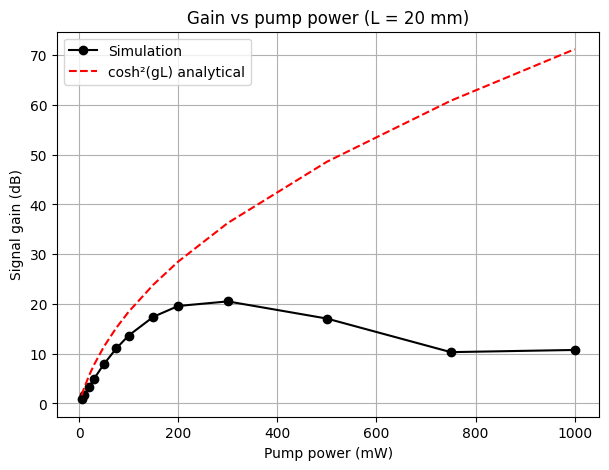

~20 dB gain at P_pump ≈ 200 mW (L = 20 mm)


In [6]:
L_fixed = 20 * mm
P_sweep = np.array([5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 500, 750, 1000]) * 1e-3
G_sweep = [run_opa(P, L_fixed)[0] for P in P_sweep]

# Analytical prediction
g_sweep = gamma * np.sqrt(P_sweep)
G_analytical = 10*np.log10(np.cosh(g_sweep * L_fixed)**2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(P_sweep*1e3, G_sweep, 'ko-', label='Simulation')
ax.plot(P_sweep*1e3, G_analytical, 'r--', label='cosh²(gL) analytical')
ax.set_xlabel('Pump power (mW)')
ax.set_ylabel('Signal gain (dB)')
ax.set_title(f'Gain vs pump power (L = {L_fixed/mm:.0f} mm)')
ax.legend()
ax.grid(True)
plt.show()

# Find pump power for 20 dB gain
G_arr = np.array(G_sweep)
idx_20 = np.argmin(np.abs(G_arr - 20))
print(f'~20 dB gain at P_pump ≈ {P_sweep[idx_20]*1e3:.0f} mW (L = {L_fixed/mm:.0f} mm)')

## Cell 4 — Effect of Propagation Loss

CW fields experience loss over the full crystal length, unlike pulsed OPA where
the pulse exits before loss accumulates. There is a threshold pump power below
which loss wins and the device has net loss.

State-of-the-art TFLN: 0.03–0.1 dB/cm. Typical: 0.1–0.5 dB/cm.

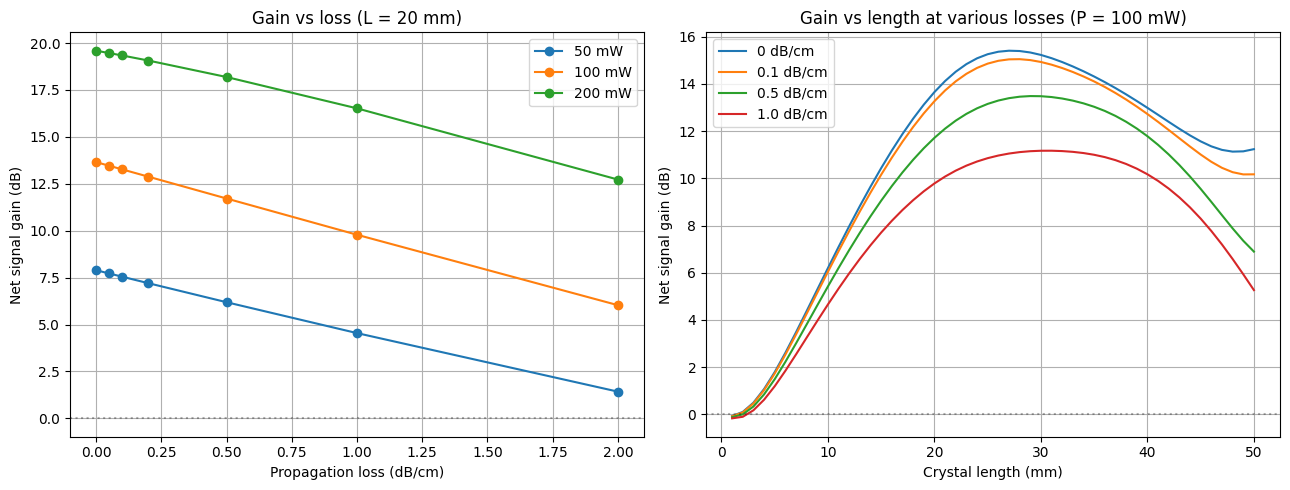

In [7]:
alpha_values = [0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
P_loss_sweep = [50e-3, 100e-3, 200e-3]
L_loss = 20 * mm

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for Pp in P_loss_sweep:
    G_loss = [run_opa(Pp, L_loss, alpha_dBcm=a)[0] for a in alpha_values]
    ax1.plot(alpha_values, G_loss, 'o-', label=f'{Pp*1e3:.0f} mW')

ax1.axhline(0, color='k', ls=':', alpha=0.3)
ax1.set_xlabel('Propagation loss (dB/cm)')
ax1.set_ylabel('Net signal gain (dB)')
ax1.set_title(f'Gain vs loss (L = {L_loss/mm:.0f} mm)')
ax1.legend()
ax1.grid(True)

# Gain vs length at different losses (P=100mW)
L_arr3 = np.arange(1, 51) * mm
for alpha in [0, 0.1, 0.5, 1.0]:
    G_Larr = [run_opa(100e-3, L, alpha_dBcm=alpha)[0] for L in L_arr3]
    ax2.plot(L_arr3/mm, G_Larr, '-', label=f'{alpha} dB/cm')

ax2.axhline(0, color='k', ls=':', alpha=0.3)
ax2.set_xlabel('Crystal length (mm)')
ax2.set_ylabel('Net signal gain (dB)')
ax2.set_title('Gain vs length at various losses (P = 100 mW)')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## Cell 5 — Gain Bandwidth

The gain bandwidth is set by the phase-matching bandwidth, which depends on
waveguide dispersion and crystal length. Longer crystals give higher peak gain
but narrower bandwidth — the fundamental gain-bandwidth tradeoff.

This cell uses a **finer grid (N=2048)** for sub-nm wavelength resolution.
The coarse N=256 grid used elsewhere has df ≈ 830 GHz (~6.6 nm at 1550 nm),
too coarse to resolve the bandwidth shape. Scaling to N=2048 gives
df ≈ 104 GHz (~0.83 nm) with 200+ points across the C-band.

Fine grid: N=4096, df=51.9 GHz (Δλ ≈ 0.42 nm at 1550 nm)
Sweep: 1490–1610 nm, 289 points


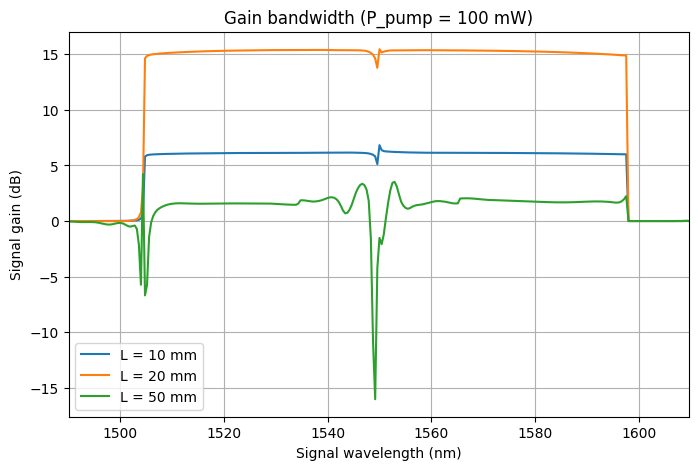

  L = 10 mm done
  L = 20 mm done
  L = 50 mm done


In [8]:
# --- Fine grid for bandwidth sweep ---
# Scale integer frequency indices to get finer spectral resolution
# while preserving exact energy conservation (M_pump = M_signal + M_idler).

SCALE = 16
N_bw = N * SCALE                        # 4096
M_pump_bw = M_pump * SCALE              # 7456
M_sig_center_bw = M_signal * SCALE      # 3744 (design-center signal)

df_bw = c / (lam_pump * M_pump_bw)      # finer df
dt_bw = 1 / (N_bw * df_bw)
t_bw = np.arange(N_bw) * dt_bw

k_pump_bw = k_pump * SCALE              # 1792
R_bw = M_pump_bw - k_pump_bw            # 5664
f_ref_bw = R_bw * df_bw
lam_ref_bw = c / f_ref_bw

f_abs_bw = fftfreq(N_bw, dt_bw) + f_ref_bw

# v_ref and Kg for the fine grid (same physics, recomputed for new beta_ref)
beta_ref_bw = wg.beta(np.array([lam_ref_bw]), T=T_op)[0]
v_ref_bw = 2*pi * f_ref_bw / (beta_ref_bw + Kg)   # same Kg as before

print(f'Fine grid: N={N_bw}, df={df_bw/1e9:.1f} GHz '
      f'(Δλ ≈ {(1550*nm)**2 * df_bw / c / nm:.2f} nm at 1550 nm)')

# --- Bandwidth sweep ---
# Focus on the parametric gain bandwidth (±40 nm from center).
# Features further out are dominated by parasitic SHG/SFG processes
# that happen to be phase-matched through the same QPM grating.

P_pump_bw = 100e-3
L_crystals = [10*mm, 20*mm, 50*mm]

# Signal range: ~1490–1610 nm (center ± 60 nm)
lam_center = c / (M_sig_center_bw * df_bw)
M_s_lo = int(np.ceil(c / (1610*nm) / df_bw))
M_s_hi = int(np.floor(c / (1490*nm) / df_bw))
M_s_range_bw = np.arange(M_s_lo, M_s_hi + 1)
lam_s_range_bw = c / (M_s_range_bw * df_bw)

print(f'Sweep: {lam_s_range_bw[-1]/nm:.0f}–{lam_s_range_bw[0]/nm:.0f} nm, '
      f'{len(M_s_range_bw)} points')

from IPython.display import display

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlabel('Signal wavelength (nm)')
ax.set_ylabel('Signal gain (dB)')
ax.set_title(f'Gain bandwidth (P_pump = {P_pump_bw*1e3:.0f} mW)')
ax.set_xlim(lam_s_range_bw[-1]/nm, lam_s_range_bw[0]/nm)
ax.grid(True)
fig_handle = display(fig, display_id=True)
plt.ion()

for L_bw in L_crystals:
    line, = ax.plot([], [], '-', label=f'L = {L_bw/mm:.0f} mm')
    ax.legend()
    lams_so_far, G_so_far = [], []
    wg.set_length(L_bw)
    wg.set_loss(0)
    for Ms in M_s_range_bw:
        Mi = M_pump_bw - Ms
        ks = Ms - R_bw + N_bw
        ki = Mi - R_bw + N_bw
        if not (0 <= ks < N_bw and 0 <= ki < N_bw):
            continue

        df_p_bb = M_pump_bw * df_bw - f_ref_bw
        df_s_bb = Ms * df_bw - f_ref_bw
        x = (np.sqrt(P_pump_bw) * np.exp(1j*2*pi*df_p_bb*t_bw) +
             np.sqrt(P_signal_in) * np.exp(1j*2*pi*df_s_bb*t_bw))
        p_in = pulses.pulse(t_bw, x, lam_ref_bw, frep=1e9)

        out, _ = wg.propagate_NEE(p_in, v_ref=v_ref_bw, verbose=False,
                                  T=T_op, Kg=Kg)
        A_out = fft(out.a)
        Ps_out = np.abs(A_out[ks])**2 / N_bw**2
        lams_so_far.append(c / (Ms * df_bw) / nm)
        G_so_far.append(10*np.log10(Ps_out / P_signal_in))

        line.set_data(lams_so_far, G_so_far)
        ax.relim(); ax.autoscale_view(scalex=False)
        fig_handle.update(fig)

    print(f'  L = {L_bw/mm:.0f} mm done')

plt.close(fig)

## Cell 6 — Phase-Sensitive Operation

Inject **both** signal and idler at the input with equal amplitudes and sweep
the relative phase θ = φ_pump − φ_signal − φ_idler from 0 to 2π.

For a perfectly phase-matched PS-OPA in the undepleted pump regime:
- Maximum gain: G_max = exp(2gL) ≈ 2 × G_PI (in dB)
- Minimum gain: G_min = exp(−2gL) (deamplification)

**Phase mismatch note:** Even with QPM, residual Δk causes θ to evolve along z.
For the designed wavelength pair, Δk − Kg ≈ 0 and the input phase maps cleanly.
At detuned wavelengths, the phase sensitivity would be washed out.

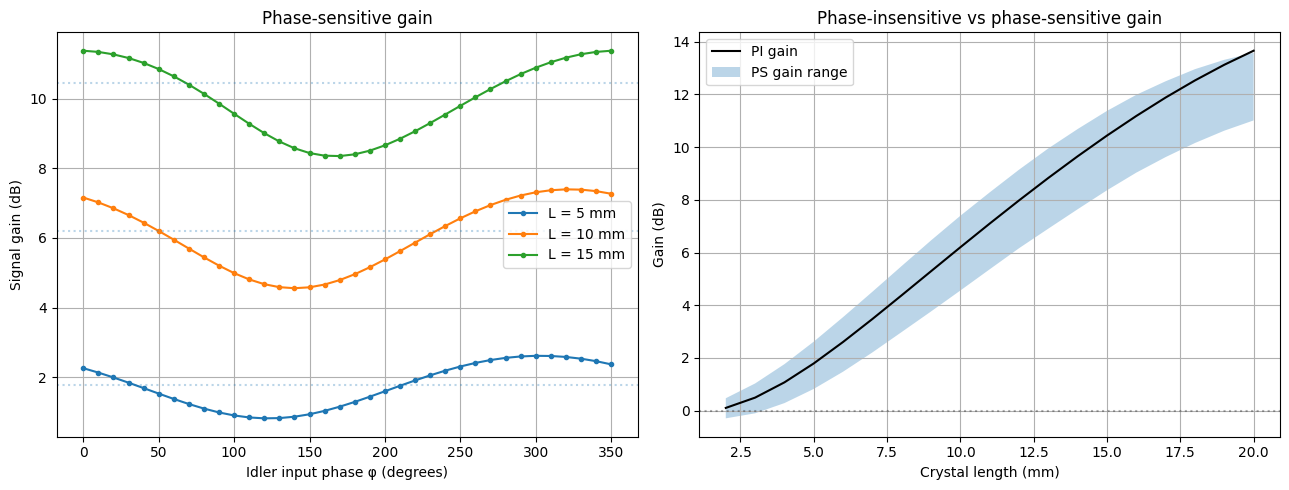

In [9]:
# Phase-sensitive OPA: sweep idler input phase
P_pump_ps = 100e-3
L_ps_values = [5*mm, 10*mm, 15*mm]
phi_sweep = np.linspace(0, 2*pi, 36, endpoint=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for L_ps in L_ps_values:
    G_ps = []
    for phi in phi_sweep:
        G, _, _, _ = run_opa(P_pump_ps, L_ps, P_idler=P_signal_in, phi_idler=phi)
        G_ps.append(G)
    ax1.plot(np.degrees(phi_sweep), G_ps, 'o-', ms=3,
             label=f'L = {L_ps/mm:.0f} mm')
    
    # Also get PI gain for comparison
    G_pi, _, _, _ = run_opa(P_pump_ps, L_ps)
    ax1.axhline(G_pi, ls=':', alpha=0.3)

ax1.set_xlabel('Idler input phase φ (degrees)')
ax1.set_ylabel('Signal gain (dB)')
ax1.set_title('Phase-sensitive gain')
ax1.legend()
ax1.grid(True)

# Compare PI vs PS gain range
L_compare = np.arange(2, 21) * mm
G_pi_arr, G_ps_max, G_ps_min = [], [], []
for L in L_compare:
    G_pi, _, _, _ = run_opa(P_pump_ps, L)
    G_pi_arr.append(G_pi)
    G_ps_vals = [run_opa(P_pump_ps, L, P_idler=P_signal_in, phi_idler=phi)[0]
                 for phi in np.linspace(0, 2*pi, 18, endpoint=False)]
    G_ps_max.append(max(G_ps_vals))
    G_ps_min.append(min(G_ps_vals))

ax2.plot(L_compare/mm, G_pi_arr, 'k-', label='PI gain')
ax2.fill_between(L_compare/mm, G_ps_min, G_ps_max, alpha=0.3, label='PS gain range')
ax2.axhline(0, color='k', ls=':', alpha=0.3)
ax2.set_xlabel('Crystal length (mm)')
ax2.set_ylabel('Gain (dB)')
ax2.set_title('Phase-insensitive vs phase-sensitive gain')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

##### Cell 7 — Summary

| Parameter | Bulk pulsed OPA (Tutorial 8) | CW waveguide OPA (this notebook) |
|---|---|---|
| Pump power/energy | µJ pulses | mW–W CW |
| Peak intensity | GW/cm² | MW/cm² |
| Gain per pass | 20–60 dB | 5–20 dB |
| Bandwidth | nm–tens of nm | nm–tens of nm (engineerable) |
| Key limitation | GVM, back-conversion | Propagation loss, pump power |
| Key advantage | High energy output | Low noise, integrability |
| Application | Spectroscopy, ultrafast | Telecom amplification, quantum |

### Key simulation findings

1. **X0 = 1.1e-12 is well-calibrated:** γ = g/√P matches Mishra et al. (2025)
   within ~1%, validating SNOW's waveguide coupling coefficient for this
   wavelength range. The factor-of-20 mystery from the bulk notebook is indeed
   a bulk-vs-waveguide normalization issue.

2. **CW on a discrete grid requires exact energy conservation:** The pump, signal,
   and idler must satisfy f_pump = f_signal + f_idler as integer multiples of df.
   Even a ~1 bin mismatch kills the parametric coupling.

3. **Carrier-phase-minimizing v_ref is essential:** Setting v_ref = Ω_ref/(β_ref + Kg)
   makes the carrier phase static (φ₂ ≈ 0), allowing the RK45 integrator to
   take large steps. Without this, the carrier oscillates at ~27 µm period and
   the integrator can't resolve it.

4. **~200 mW pump gives ~20 dB gain in 20 mm:** Consistent with state-of-the-art
   TFLN PPLN waveguide OPAs. Back-conversion sets in above ~200 mW at this length.